<a href="https://colab.research.google.com/github/roneyreissilva/Projeto_Neocard/blob/main/Notebook_Neocard_Roney.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJETO FINAL NEOCARD**

In [134]:
### importando Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
### Carrengando Dataset usantdo sheet_name para carregar as diferentes pastas do Dataset
df_clientes = pd.read_excel('https://github.com/roneyreissilva/Projeto_Neocard/raw/refs/heads/main/neocard_dataset.xlsx', sheet_name='clientes')
df_transacoes = pd.read_excel('https://github.com/roneyreissilva/Projeto_Neocard/raw/refs/heads/main/neocard_dataset.xlsx', sheet_name='transacoes')
print(df_clientes.head())

   id_cliente  idade    regiao segmento_cartao  score_credito  limite_credito  \
0         556     37  Nordeste         Classic          591.0        16069.40   
1        3492     31     Norte         Classic            NaN        15597.73   
2         528     61  Nordeste           Black          805.0        24925.36   
3        3926     38       Sul            Gold            NaN        16385.55   
4        2990     26       Sul            Gold          622.0        15328.19   

   tempo_relacionamento_meses  canal_aquisicao             produto_core  
0                         142        Indicação  Cartão Múltiplo NeoCard  
1                         100        Indicação  Cartão Múltiplo NeoCard  
2                         123          Agência  Cartão Múltiplo NeoCard  
3                         201              App  Cartão Múltiplo NeoCard  
4                         186  Parceria Varejo  Cartão Múltiplo NeoCard  


## Tratamento do DATASET (procurando dados faltantes, outliers e analisando como tratar cada caso)

In [113]:
print (df_clientes.isnull().sum())

id_cliente                      0
idade                           0
regiao                          0
segmento_cartao                 0
score_credito                 180
limite_credito                  0
tempo_relacionamento_meses      0
canal_aquisicao                 0
produto_core                    0
dtype: int64


##Alterando valores de células vazias
Verifica-se aqui a existência de 180 registros faltantes na coluna score_credito. Decidi não chutar um número para os 180 clientes, mas sim tratá-los como um grupo à parte, já que a ausência de score também é uma informação importante para o negócio, sendo assim, decidi criar uma Categoria "Nao_Informado".

In [114]:
df_clientes['score_credito'] = df_clientes['score_credito'].fillna('Nao_Informado')

# Salva a planilha corrigida
df_clientes.to_excel('neocard_dataset_atualizado.xlsx', index=False)

# Mostra na tela a contagem para você conferir o resultado
print(df_clientes['score_credito'].value_counts())

score_credito
Nao_Informado    180
619.0             30
588.0             30
560.0             26
591.0             26
                ... 
469.0              1
889.0              1
839.0              1
849.0              1
844.0              1
Name: count, Length: 395, dtype: int64


## Verificando existência de Outliers na coluna 'idade'
Aqui vamos apurar o valor min e max da coluna 'idade'

In [115]:
# printar valores min e max da coluna 'idade'
print(max(df_clientes['idade']))
print(min(df_clientes['idade']))

200
-5


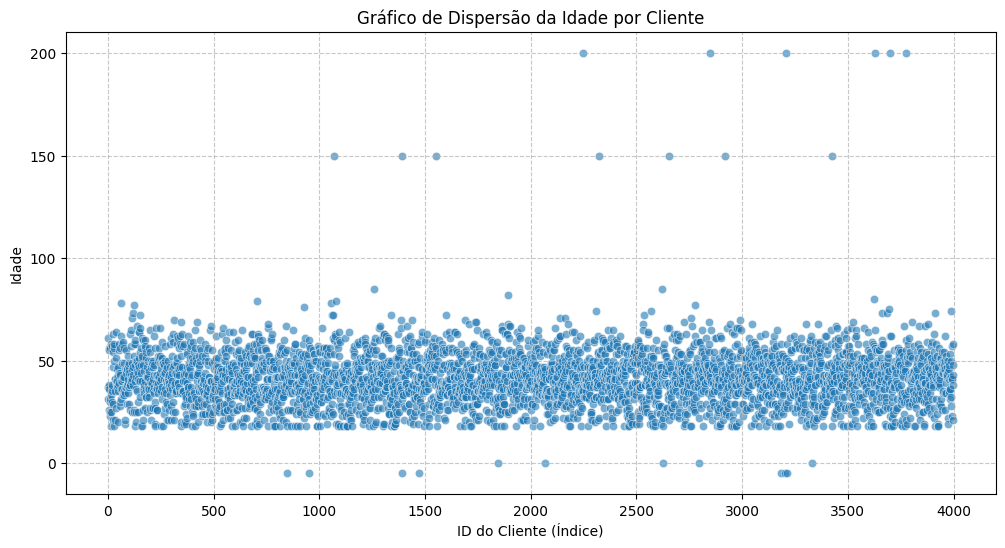

In [116]:
# Vamos criar um gráfico de dispersão para nos ajudar a visualizar a quantidade dessas idades atípicas
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df_clientes.index, y=df_clientes['idade'], alpha=0.6)
plt.title('Gráfico de Dispersão da Idade por Cliente')
plt.xlabel('ID do Cliente (Índice)')
plt.ylabel('Idade')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Tratamento de Outliers na Coluna 'Idade'

O gráfico de dispersão acima nos ajudou a constatar que a coluna 'idade' apresenta valores atípicos (negativos e muito altos). Vamos filtrar esses outliers para ter uma análise mais representativa da distribuição de idade. Para isso, vamos filtrar todos os clientes no DataFrame `df_clientes` adotando como critério um intervalo de idade entre 18 e 90 anos.

In [117]:
# Aplicar o filtro de idade (18 a 90 anos) a todos os clientes no DataFrame df_clientes
df_clientes = df_clientes[(df_clientes['idade'] >= 18) & (df_clientes['idade'] <= 90)]

print(max(df_clientes['idade']))
print(min(df_clientes['idade']))

85
18


### Análise do Impacto dos Outliers na Média de Idade

Vamos comparar a média de idade antes (usando o DataFrame original `df`) e depois do tratamento dos *outliers* (usando o DataFrame `df_clientes` filtrado para idades entre 18 e 90 anos).

In [118]:
# Média de idade antes do tratamento (usando o DataFrame 'df' original)
media_idade_antes = df_clientes_original_temp['idade'].mean()
print(f"Média de Idade Antes do Tratamento: {media_idade_antes:.2f} anos")

# Média de idade depois do tratamento (usando o DataFrame 'df_clientes' filtrado)
media_idade_depois = df_clientes['idade'].mean()
print(f"Média de Idade Depois do Tratamento: {media_idade_depois:.2f} anos")

# Cálculo do impacto
impacto_percentual = ((media_idade_antes - media_idade_depois) / media_idade_antes) * 100
print(f"O impacto na média de idade foi de aproximadamente {abs(impacto_percentual):.2f}% (redução)")

Média de Idade Antes do Tratamento: 41.22 anos
Média de Idade Depois do Tratamento: 40.93 anos
O impacto na média de idade foi de aproximadamente 0.72% (redução)


### Análise de Outliers na Coluna 'limite_credito'

Vamos agora focar na coluna `limite_credito` para identificar e analisar possíveis *outliers*. Primeiramente, vamos visualizar a distribuição e obter algumas estatísticas descritivas.Para ajudar nessa missão, escolhi o Gráfico de Dispersão que permitiu a melhor visualização destes outliers.

Estatísticas Descritivas para a coluna limite_credito:


,limite_credito
count,3975.000000
mean,16896.189741
std,15565.960798
min,8124.240000
25%,14356.070000
50%,15905.030000
75%,17768.070000
max,395222.440000


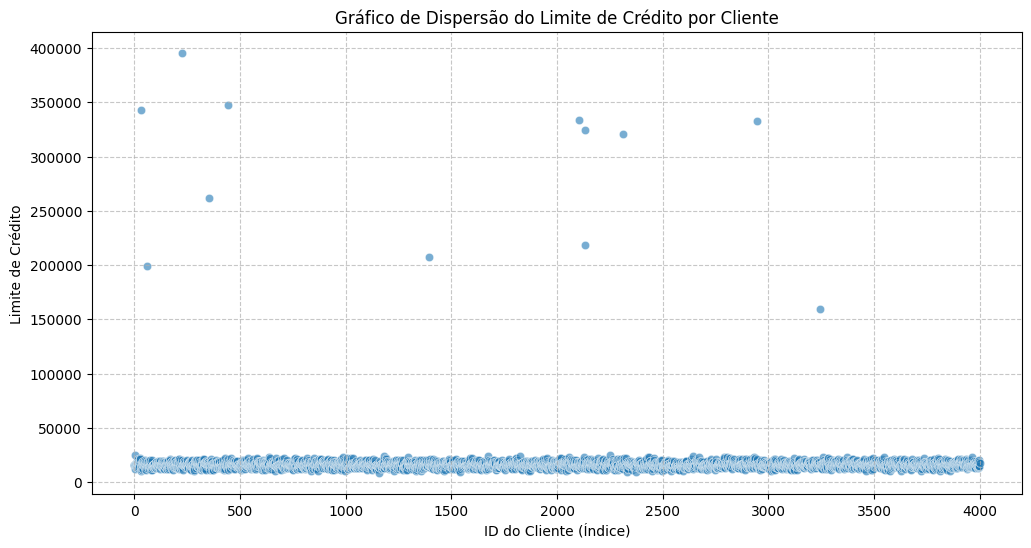

In [119]:
print('Estatísticas Descritivas para a coluna limite_credito:')
display(df_clientes['limite_credito'].describe())

plt.figure(figsize=(12, 6))
sns.scatterplot(x=df_clientes.index, y=df_clientes['limite_credito'], alpha=0.6)
plt.title('Gráfico de Dispersão do Limite de Crédito por Cliente')
plt.xlabel('ID do Cliente (Índice)')
plt.ylabel('Limite de Crédito')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Removendo Outliers da Coluna 'limite_credito' com o Método IQR

Agora que visualizamos os *outliers* no `limite_credito`. Optei por removê-los usando o método do Intervalo Interquartil (IQR), pois, nitidamente, o Gráfico de Dispersão consegue nos mostrar os poucos valores constantes no ultimo quartil, que ficam muito acima dos demais.

In [120]:
# Calcular Q1 (primeiro quartil) e Q3 (terceiro quartil)
Q1 = df_clientes['limite_credito'].quantile(0.25)
Q3 = df_clientes['limite_credito'].quantile(0.75)
IQR = Q3 - Q1

# Definir limites para outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite Inferior para Outliers: {limite_inferior:.2f}")
print(f"Limite Superior para Outliers: {limite_superior:.2f}")

# Contar o número de outliers
outliers_limite_credito = df_clientes[(df_clientes['limite_credito'] < limite_inferior) | (df_clientes['limite_credito'] > limite_superior)]
num_outliers_removidos = len(outliers_limite_credito)

# Filtrar o DataFrame para remover os outliers
df_clientes_sem_outliers_limite = df_clientes[(df_clientes['limite_credito'] >= limite_inferior) & (df_clientes['limite_credito'] <= limite_superior)].copy()

print(f"\nNúmero de Outliers de 'limite_credito' removidos: {num_outliers_removidos}")
print(f"Número de registros após remoção de outliers: {len(df_clientes_sem_outliers_limite)}")

# Exibir estatísticas descritivas do limite de crédito após a remoção dos outliers
print("\nEstatísticas Descritivas para a coluna 'limite_credito' (após remoção de outliers):")
display(df_clientes_sem_outliers_limite['limite_credito'].describe())

# Comparar a média antes e depois da remoção
media_antes_outliers = df_clientes['limite_credito'].mean()
media_depois_outliers = df_clientes_sem_outliers_limite['limite_credito'].mean()
impacto_percentual_limite = ((media_antes_outliers - media_depois_outliers) / media_antes_outliers) * 100

# Salva a planilha corrigida
df_clientes_sem_outliers_limite.to_excel('neocard_dataset_atualizado.xlsx', index=False)

print(f"Média do Limite de Crédito Antes da Remoção de Outliers: {media_antes_outliers:.2f}")
print(f"Média do Limite de Crédito Depois da Remoção de Outliers: {media_depois_outliers:.2f}")
print(f"Impacto na média do limite de crédito: {abs(impacto_percentual_limite):.2f}% de redução")

Q1: 14356.07
Q3: 17768.07
IQR: 3412.00
Limite Inferior para Outliers: 9238.07
Limite Superior para Outliers: 22886.07

Número de Outliers de 'limite_credito' removidos: 33
Número de registros após remoção de outliers: 3942

Estatísticas Descritivas para a coluna 'limite_credito' (após remoção de outliers):


,limite_credito
count,3942.000000
mean,16046.520452
std,2419.638210
min,9335.320000
25%,14345.892500
50%,15882.275000
75%,17710.177500
max,22835.990000


Média do Limite de Crédito Antes da Remoção de Outliers: 16896.19
Média do Limite de Crédito Depois da Remoção de Outliers: 16046.52
Impacto na média do limite de crédito: 5.03% de redução


22835.99
9335.32


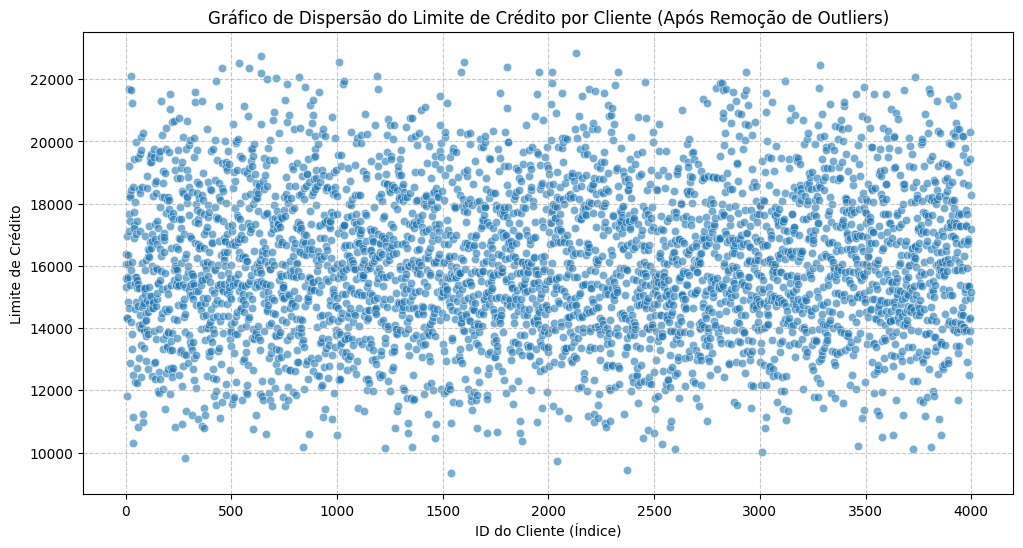

In [121]:
# print max e min
print(max(df_clientes_sem_outliers_limite['limite_credito']))
print(min(df_clientes_sem_outliers_limite['limite_credito']))

# Visualizar a distribuição do limite de crédito após a remoção dos outliers com um scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df_clientes_sem_outliers_limite.index, y=df_clientes_sem_outliers_limite['limite_credito'], alpha=0.6)
plt.title('Gráfico de Dispersão do Limite de Crédito por Cliente (Após Remoção de Outliers)')
plt.xlabel('ID do Cliente (Índice)')
plt.ylabel('Limite de Crédito')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#Limpando os dados da coluna Categoria na Tabela Df_transacoes
Necessário organizar a coluna acima, excluindo duplicidades de categoria por erros na grafia

In [122]:
print("Contagem de registros por categoria após padronização:")
display(df_transacoes['categoria'].value_counts())

Contagem de registros por categoria após padronização:


,count
categoria,
Supermercado,46826
Restaurante,33924
Vestuário,21438
Combustível,21348
Farmácia,19026
Eletrônicos,17024
Outros,16956
Streaming,12891
Viagem,12731


Diante das duplicidades, optei aqui por padronizar valores da coluna 'categoria' como minuscúlas e sem acentuação

### Padronizando a Coluna 'categoria'

Para eliminar as duplicidades causadas por diferenças de maiúsculas/minúsculas e acentuação, vamos padronizar todos os valores da coluna 'categoria' para minúsculas e remover quaisquer acentos ou caracteres especiais (incluindo o 'ç').

In [123]:
import unicodedata

def remover_acentos_e_minusculas(texto):
    if isinstance(texto, str):
        nfkd_form = unicodedata.normalize('NFKD', texto)
        # Remove caracteres diacríticos (acentos) e converte para minúsculas
        texto_sem_acentos = ''.join([c for c in nfkd_form if not unicodedata.combining(c)])
        return texto_sem_acentos.lower().replace('ç', 'c') # Lida com 'ç' especificamente
    return texto

# Aplicar a função à coluna 'categoria' do DataFrame df_transacoes
df_transacoes['categoria'] = df_transacoes['categoria'].apply(remover_acentos_e_minusculas)

# Salva a planilha corrigida
df_transacoes.to_excel('neocard_dataset_atualizado.xlsx', index=False)

print("Valores únicos na coluna 'categoria' após padronização (minúsculas e sem acentos):")
display(df_transacoes['categoria'].unique())

print("\nContagem de registros por categoria após padronização:")
display(df_transacoes['categoria'].value_counts())

Valores únicos na coluna 'categoria' após padronização (minúsculas e sem acentos):


array(['supermercado', 'eletronicos', 'restaurante', 'vestuario',
       'outros', 'combustivel', 'streaming', 'viagem', 'farmacia',
       'educacao'], dtype=object)


Contagem de registros por categoria após padronização:


,count
categoria,
supermercado,47552
restaurante,34438
vestuario,21752
combustivel,21691
farmacia,19323
eletronicos,17250
outros,17209
streaming,13094
viagem,12939


### Partindo para a Estatística descritiva com os dados Limpos

### Estatísticas Descritivas Gerais da Base de Clientes (Dados Limpos)

Vamos analisar as principais métricas para `idade`, `score_credito` e `limite_credito` na base de clientes após a limpeza de *outliers*.

In [124]:
print("Estatísticas Descritivas para a Idade:")
display(df_clientes_sem_outliers_limite['idade'].describe().astype(int))

print("\nEstatísticas Descritivas para o Limite de Crédito:")
display(df_clientes_sem_outliers_limite['limite_credito'].describe().round(2))


Estatísticas Descritivas para a Idade:


,idade
count,3942
mean,40
std,11
min,18
25%,33
50%,41
75%,49
max,85



Estatísticas Descritivas para o Limite de Crédito:


,limite_credito
count,3942.00
mean,16046.52
std,2419.64
min,9335.32
25%,14345.89
50%,15882.28
75%,17710.18
max,22835.99


In [125]:
print("\nEstatísticas Descritivas para o Score de Crédito:")
display(df_clientes_sem_outliers_limite['score_credito'].describe())

print("\nContagem de Categorias para o Score de Crédito:")
display(df_clientes_sem_outliers_limite['score_credito'].value_counts())



Estatísticas Descritivas para o Score de Crédito:


,score_credito
count,3942
unique,389
top,Nao_Informado
freq,179



Contagem de Categorias para o Score de Crédito:


,count
score_credito,
Nao_Informado,179
619.0,30
588.0,30
560.0,26
591.0,26
...,...
469.0,1
889.0,1
839.0,1


### Análise por Segmento de Cartão

Agora, vamos investigar se o perfil dos clientes (idade, score, limite de crédito) muda significativamente entre os diferentes segmentos de cartão (`Classic`, `Gold`, `Platinum`, `Black`).

Primeiramente, vamos obter as estatísticas descritivas para cada segmento.

Estatísticas Descritivas por Segmento de Cartão (Idade e Limite de Crédito):


idade                                                       \
                  count       mean        std   min    25%   50%   75%   max   
segmento_cartao                                                                
Black             261.0  41.042146  12.512230  18.0  33.00  41.0  50.0  77.0   
Classic          1728.0  41.093750  12.153544  18.0  32.75  41.0  49.0  85.0   
Gold             1099.0  40.519563  11.349006  18.0  33.00  40.0  48.0  78.0   
Platinum          675.0  40.973333  11.643284  18.0  33.00  41.0  49.0  73.0   

                limite_credito                ...                        \
                         count          mean  ...         75%       max   
segmento_cartao                               ...                         
Black                    261.0  19372.126705  ...  20594.0800  22835.99   
Classic                 1728.0  14569.245231  ...  15792.2375  22561.63   
Gold                    1099.0  16376.645833  ...  17688.5050  21952.64   
Platinum                 675.0  17974.701126  ...  19212.9000  22731.27   

                score_credito                                               \
                        count        mean        std    min     25%    50%   
segmento_cartao                                                              
Black                   261.0  779.517241  44.035701  678.0  750.00  778.0   
Classic                1728.0  579.023148  44.872638  425.0  547.75  578.0   
Gold                   1099.0  651.188353  44.479319  514.0  622.00  651.0   
Platinum                675.0  719.115556  44.436949  545.0  689.50  718.0   

                               
                   75%    max  
segmento_cartao                
Black            809.0  897.0  
Classic          610.0  720.0  
Gold             680.0  779.0  
Platinum         747.0  847.0  

[4 rows x 24 columns]

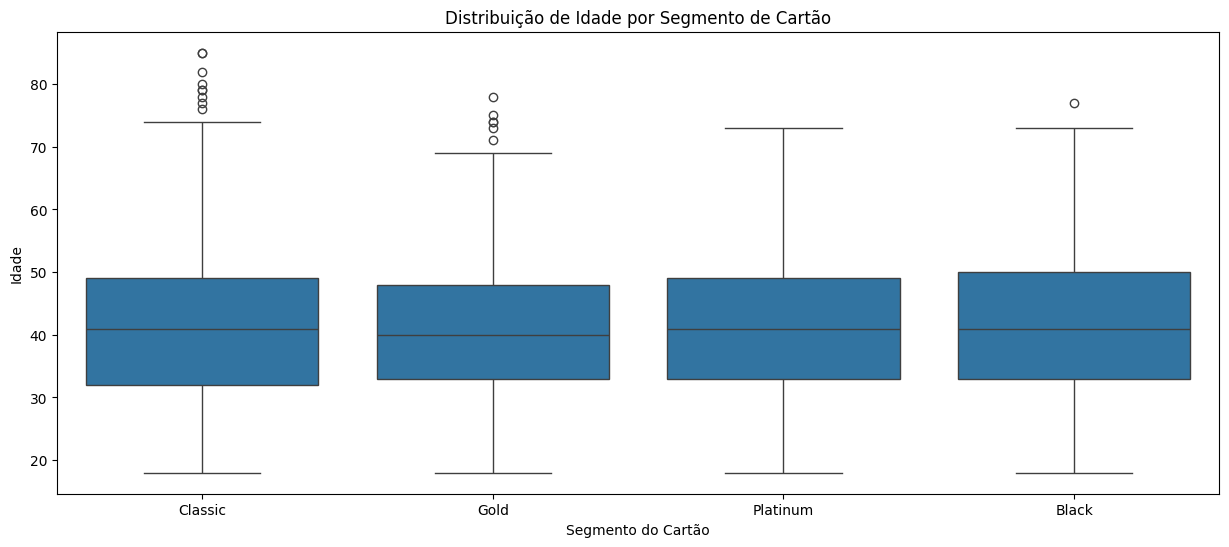

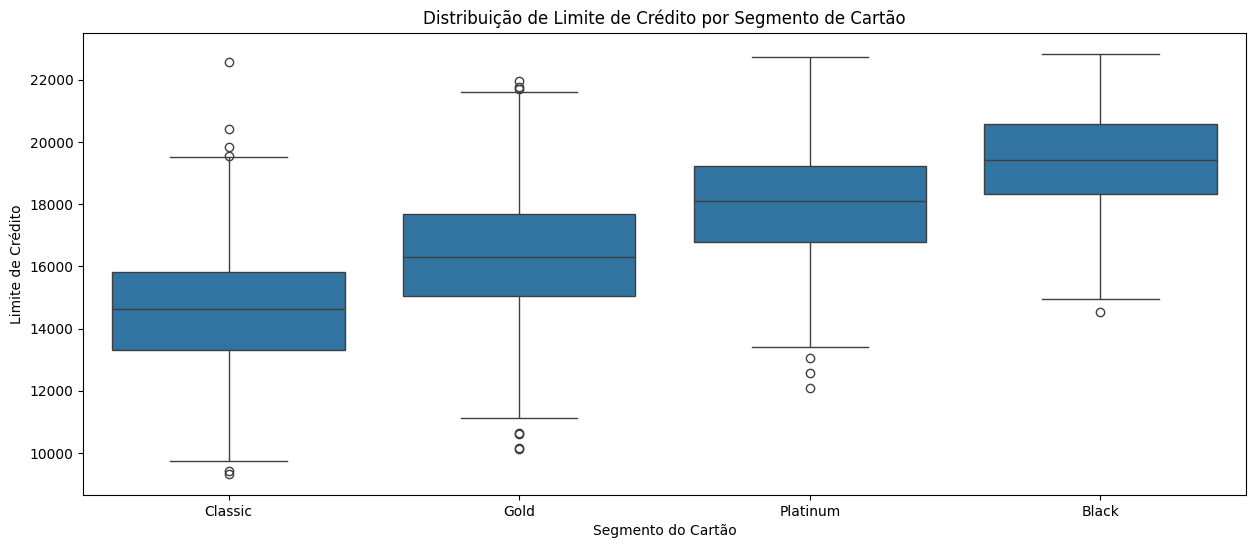

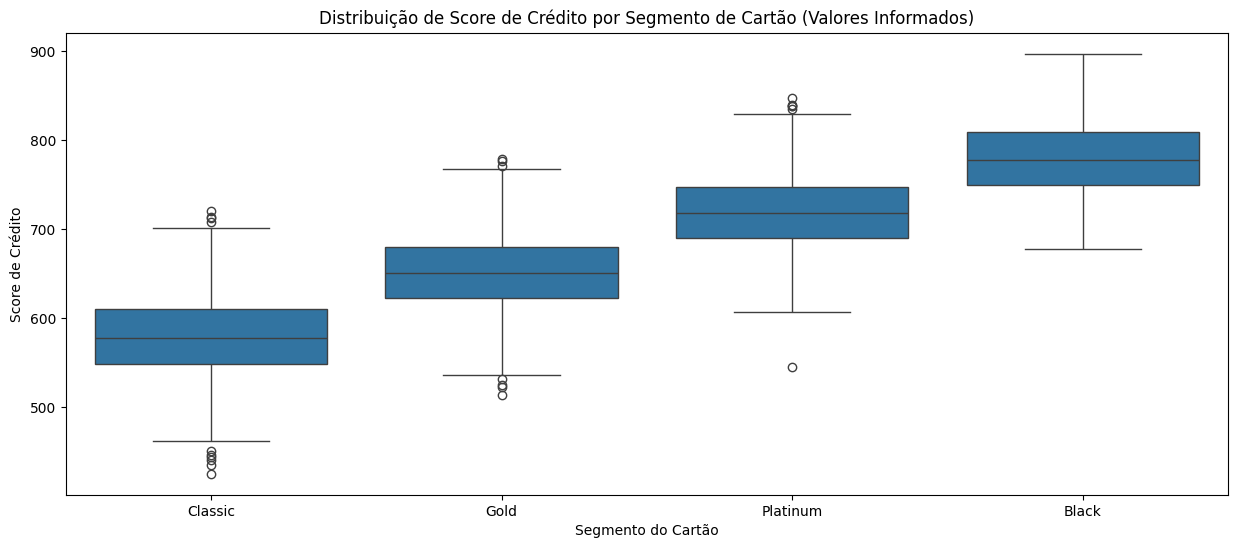

In [126]:
# Agrupar por segmento de cartão e calcular estatísticas descritivas para idade e limite_credito
print("Estatísticas Descritivas por Segmento de Cartão (Idade e Limite de Crédito):")

# Filtrar apenas scores numéricos para cálculo da média por segmento
df_segmento_numerico = df_clientes_sem_outliers_limite[df_clientes_sem_outliers_limite['score_credito'] != 'Nao_Informado'].copy()
df_segmento_numerico['score_credito'] = df_segmento_numerico['score_credito'].astype(float)

display(df_segmento_numerico.groupby('segmento_cartao')[['idade', 'limite_credito', 'score_credito']].describe())

# Visualização da distribuição de Idade por Segmento de Cartão
plt.figure(figsize=(15, 6))
sns.boxplot(x='segmento_cartao', y='idade', data=df_clientes_sem_outliers_limite)
plt.title('Distribuição de Idade por Segmento de Cartão')
plt.xlabel('Segmento do Cartão')
plt.ylabel('Idade')
plt.show()

# Visualização da distribuição de Limite de Crédito por Segmento de Cartão
plt.figure(figsize=(15, 6))
sns.boxplot(x='segmento_cartao', y='limite_credito', data=df_clientes_sem_outliers_limite)
plt.title('Distribuição de Limite de Crédito por Segmento de Cartão')
plt.xlabel('Segmento do Cartão')
plt.ylabel('Limite de Crédito')
plt.show()

# Visualização da distribuição de Score de Crédito por Segmento de Cartão (apenas valores numéricos)
plt.figure(figsize=(15, 6))
sns.boxplot(x='segmento_cartao', y='score_credito', data=df_segmento_numerico)
plt.title('Distribuição de Score de Crédito por Segmento de Cartão (Valores Informados)')
plt.xlabel('Segmento do Cartão')
plt.ylabel('Score de Crédito')
plt.show()



### Mapa de Calor das Correlações

Vamos agora visualizar as correlações entre as variáveis numéricas `idade`, `score_credito` e `limite_credito` utilizando um mapa de calor. Isso nos ajudará a identificar rapidamente a força e a direção dos relacionamentos lineares entre essas variáveis.

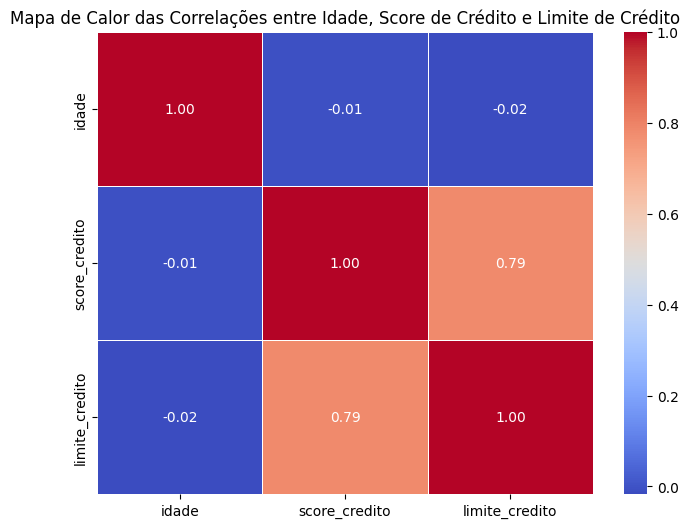

In [127]:
# Calcular a matriz de correlação
correlation_matrix = df_segmento_numerico[['idade', 'score_credito', 'limite_credito']].corr()

# Gerar o mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor das Correlações entre Idade, Score de Crédito e Limite de Crédito')
plt.show()

Percebemos acima que existe Correlação forte entre Score e Limite de crédito, oq faz todo sentido.

# Cruzando dados da Tabela Df_clientes e Df_transacoes
Cruzando estas duas tabelas afim de analisar mais profundamente o compartamento dos Clientes NeoCard, como por exemplo: volume de atividade transacional para cada combinação de segmento e região, total gasto pelos clientes em cada grupo, o valor médio que um cliente gasta por transação ou durante determinado período, dentre outras analises.

In [128]:
# Mesclar df_clientes_sem_outliers_limite com df_transacoes
df_merged = pd.merge(df_clientes_sem_outliers_limite, df_transacoes, on='id_cliente', how='inner')

# Calcular métricas agregadas por segmento e região
analise_segmento_regiao = df_merged.groupby(['segmento_cartao', 'regiao']).agg(
    numero_de_transacoes=('id_transacao', 'count'),
    gasto_total=('valor_transacao', 'sum'),
    gasto_medio_por_cliente=('valor_transacao', 'mean') # Gasto médio por transação neste contexto
).reset_index()

analise_segmento_regiao['gasto_medio_por_cliente'] = analise_segmento_regiao['gasto_medio_por_cliente'].round(2)

print("Análise Agregada por Segmento de Cartão e Região:")
display(analise_segmento_regiao)

Análise Agregada por Segmento de Cartão e Região:


,segmento_cartao,regiao,numero_de_transacoes,gasto_total,gasto_medio_por_cliente
0,Black,Centro-Oeste,3241,950270.94,296.68
1,Black,Nordeste,5926,1678853.31,286.30
2,Black,Norte,1658,458139.15,278.84
3,Black,Sudeste,12327,3413954.76,279.74
4,Black,Sul,6100,1797601.77,298.16
5,Classic,Centro-Oeste,6074,1653045.77,274.59
6,Classic,Nordeste,13401,3772686.75,284.45
7,Classic,Norte,3736,1071611.21,289.86
8,Classic,Sudeste,25787,7273823.57,285.07
9,Classic,Sul,13089,3718050.63,286.64


### Gasto Médio por Cliente por Segmento de Cartão

Vamos visualizar o gasto médio por cliente em cada segmento de cartão para entender o comportamento de compra em diferentes categorias de clientes.

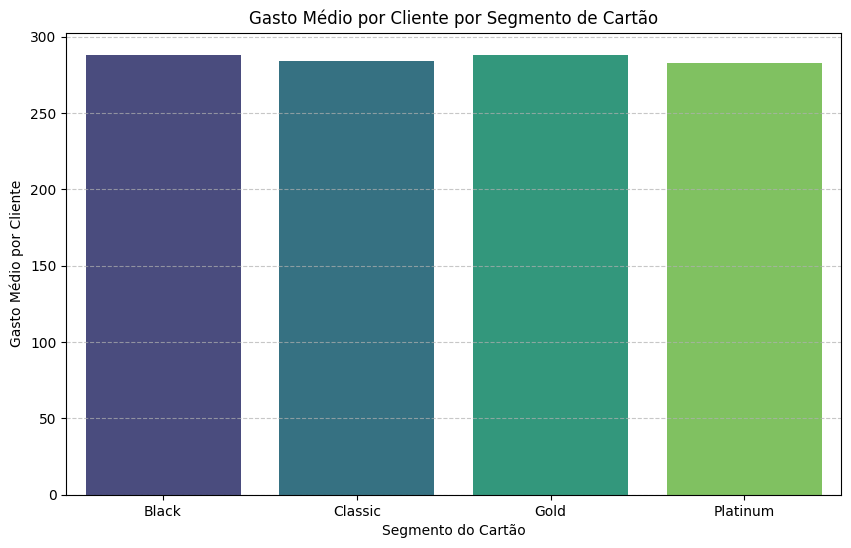

In [129]:
# Calcular o gasto médio por cliente para cada segmento de cartão
gasto_medio_por_segmento = analise_segmento_regiao.groupby('segmento_cartao')['gasto_medio_por_cliente'].mean().reset_index()

# Gerar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='segmento_cartao', y='gasto_medio_por_cliente', data=gasto_medio_por_segmento, palette='viridis', hue='segmento_cartao', legend=False)
plt.title('Gasto Médio por Cliente por Segmento de Cartão')
plt.xlabel('Segmento do Cartão')
plt.ylabel('Gasto Médio por Cliente')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Gasto Total por Região e por Segmento de Cartão

Vamos visualizar o gasto total em cada região, segmentado pelos tipos de cartão, para identificar as regiões com maior volume de transações e como os diferentes segmentos de cartão contribuem para esse total.

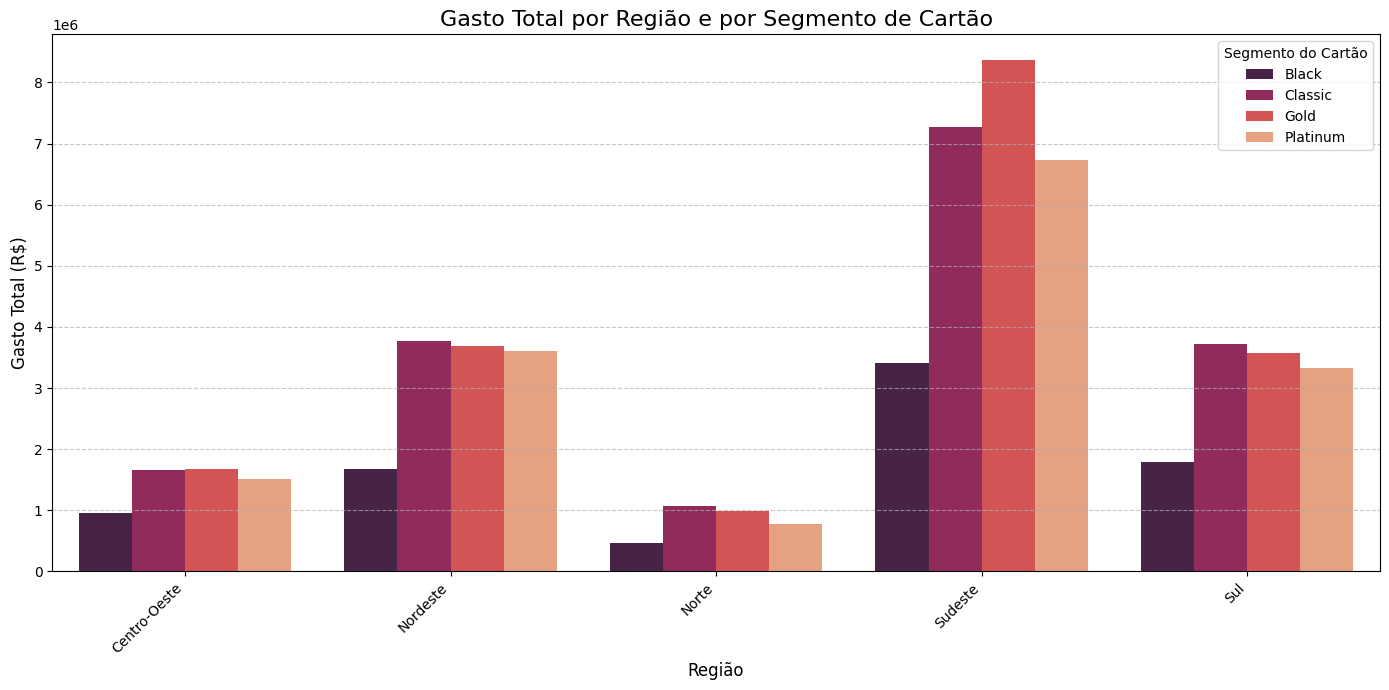

In [130]:
# Calcular o gasto total por região e por segmento de cartão
gasto_total_regiao_segmento = df_merged.groupby(['regiao', 'segmento_cartao'])['valor_transacao'].sum().reset_index()

# Gerar o gráfico de barras
plt.figure(figsize=(14, 7))
sns.barplot(x='regiao', y='valor_transacao', hue='segmento_cartao', data=gasto_total_regiao_segmento, palette='rocket')
plt.title('Gasto Total por Região e por Segmento de Cartão', fontsize=16)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Gasto Total (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Segmento do Cartão')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Gasto Total por Faixa Etária e Canal de Aquisição

Para entender melhor o comportamento de compra, vamos analisar o gasto total dos clientes, segmentado por suas faixas etárias e pelos canais através dos quais adquiriram o cartão. Isso pode revelar quais canais são mais eficazes para diferentes grupos demográficos.

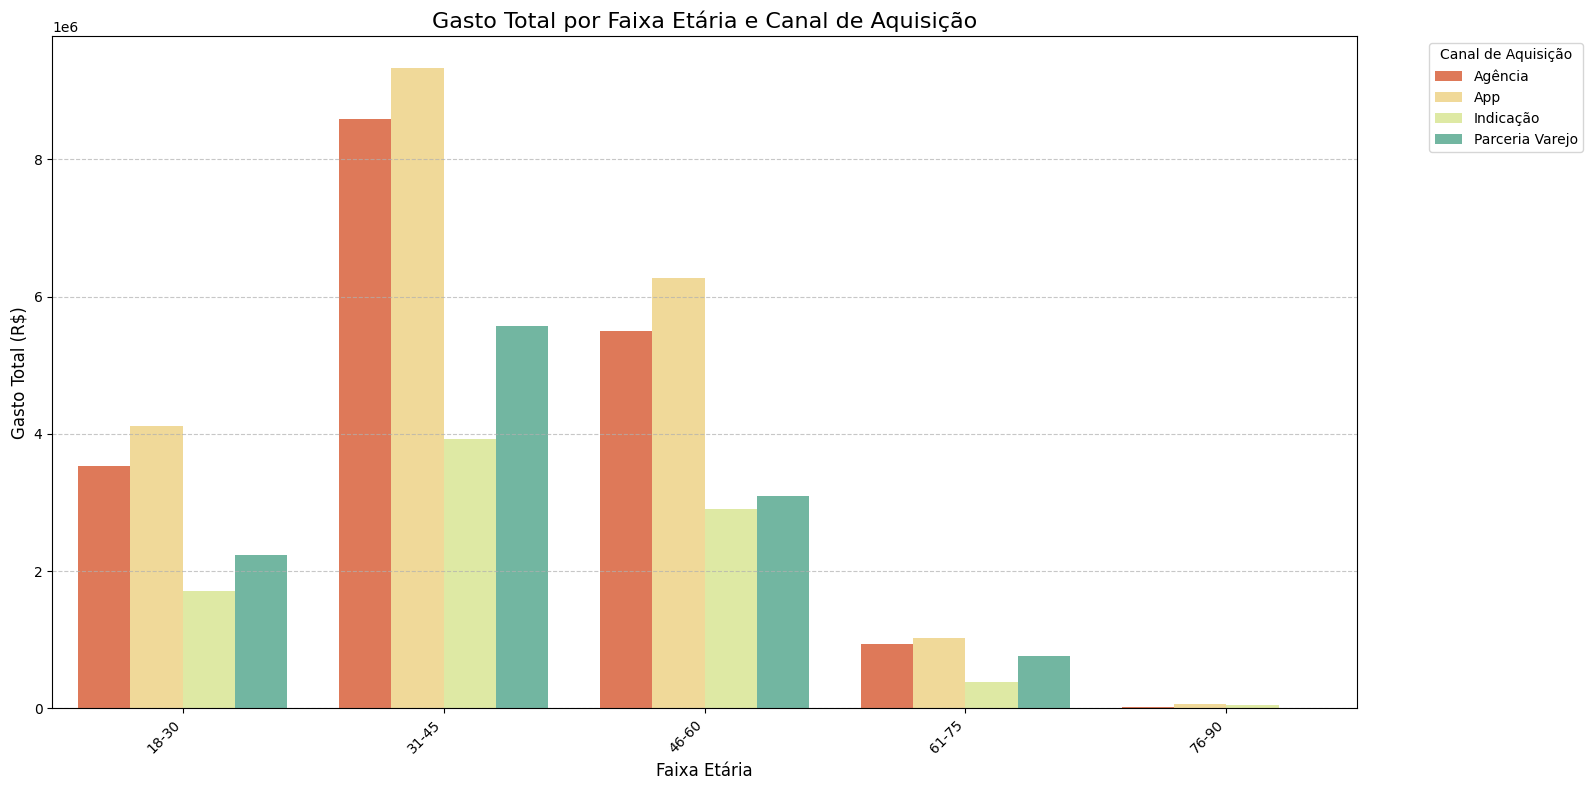

In [131]:
# Definir os limites e rótulos para as faixas etárias
bins = [18, 30, 45, 60, 75, 90]
labels = ['18-30', '31-45', '46-60', '61-75', '76-90']

# Criar a coluna 'faixa_etaria' em df_merged
df_merged['faixa_etaria'] = pd.cut(df_merged['idade'], bins=bins, labels=labels, right=True, include_lowest=True)

# Agrupar por faixa etária e canal de aquisição para calcular o gasto total
gasto_por_idade_canal = df_merged.groupby(['faixa_etaria', 'canal_aquisicao'], observed=False)['valor_transacao'].sum().reset_index()

# Criar o gráfico de barras agrupadas
plt.figure(figsize=(16, 8))
sns.barplot(data=gasto_por_idade_canal, x='faixa_etaria', y='valor_transacao', hue='canal_aquisicao', palette='Spectral')
plt.title('Gasto Total por Faixa Etária e Canal de Aquisição', fontsize=16)
plt.xlabel('Faixa Etária', fontsize=12)
plt.ylabel('Gasto Total (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Canal de Aquisição', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Gasto total por faixa etária e Canal de Transação

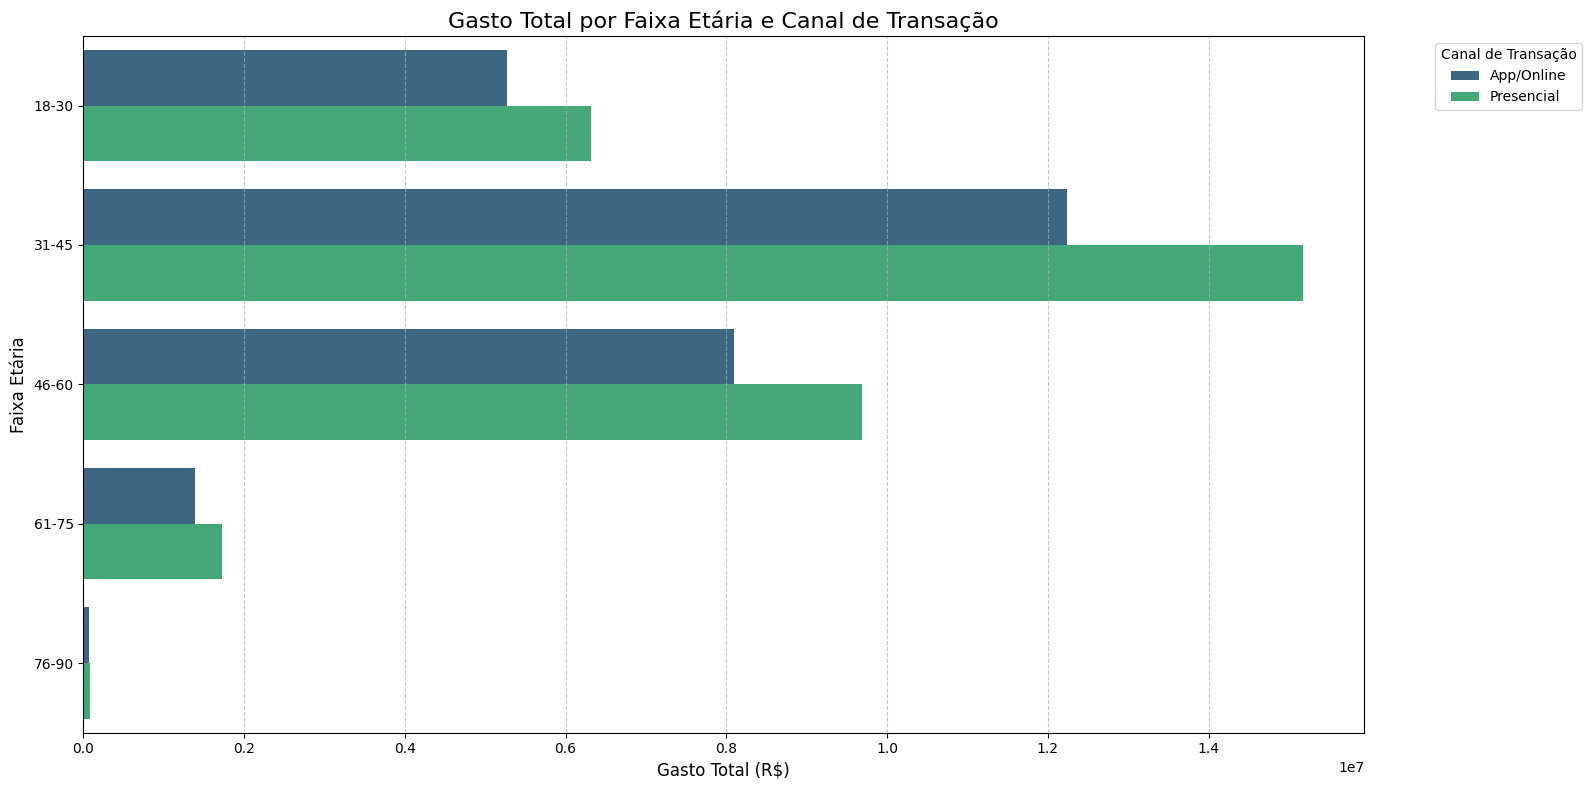

In [132]:
# Agrupar por faixa etária e canal de transação para calcular o gasto total
gasto_por_idade_canal_transacao = df_merged.groupby(['faixa_etaria', 'canal_transacao'], observed=False)['valor_transacao'].sum().reset_index()

# Criar o gráfico de barras horizontais
plt.figure(figsize=(16, 8))
sns.barplot(data=gasto_por_idade_canal_transacao, x='valor_transacao', y='faixa_etaria', hue='canal_transacao', palette='viridis')
plt.title('Gasto Total por Faixa Etária e Canal de Transação', fontsize=16)
plt.xlabel('Gasto Total (R$)', fontsize=12)
plt.ylabel('Faixa Etária', fontsize=12)
plt.legend(title='Canal de Transação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Gasto Total por Faixa Etária e Categoria de Transação

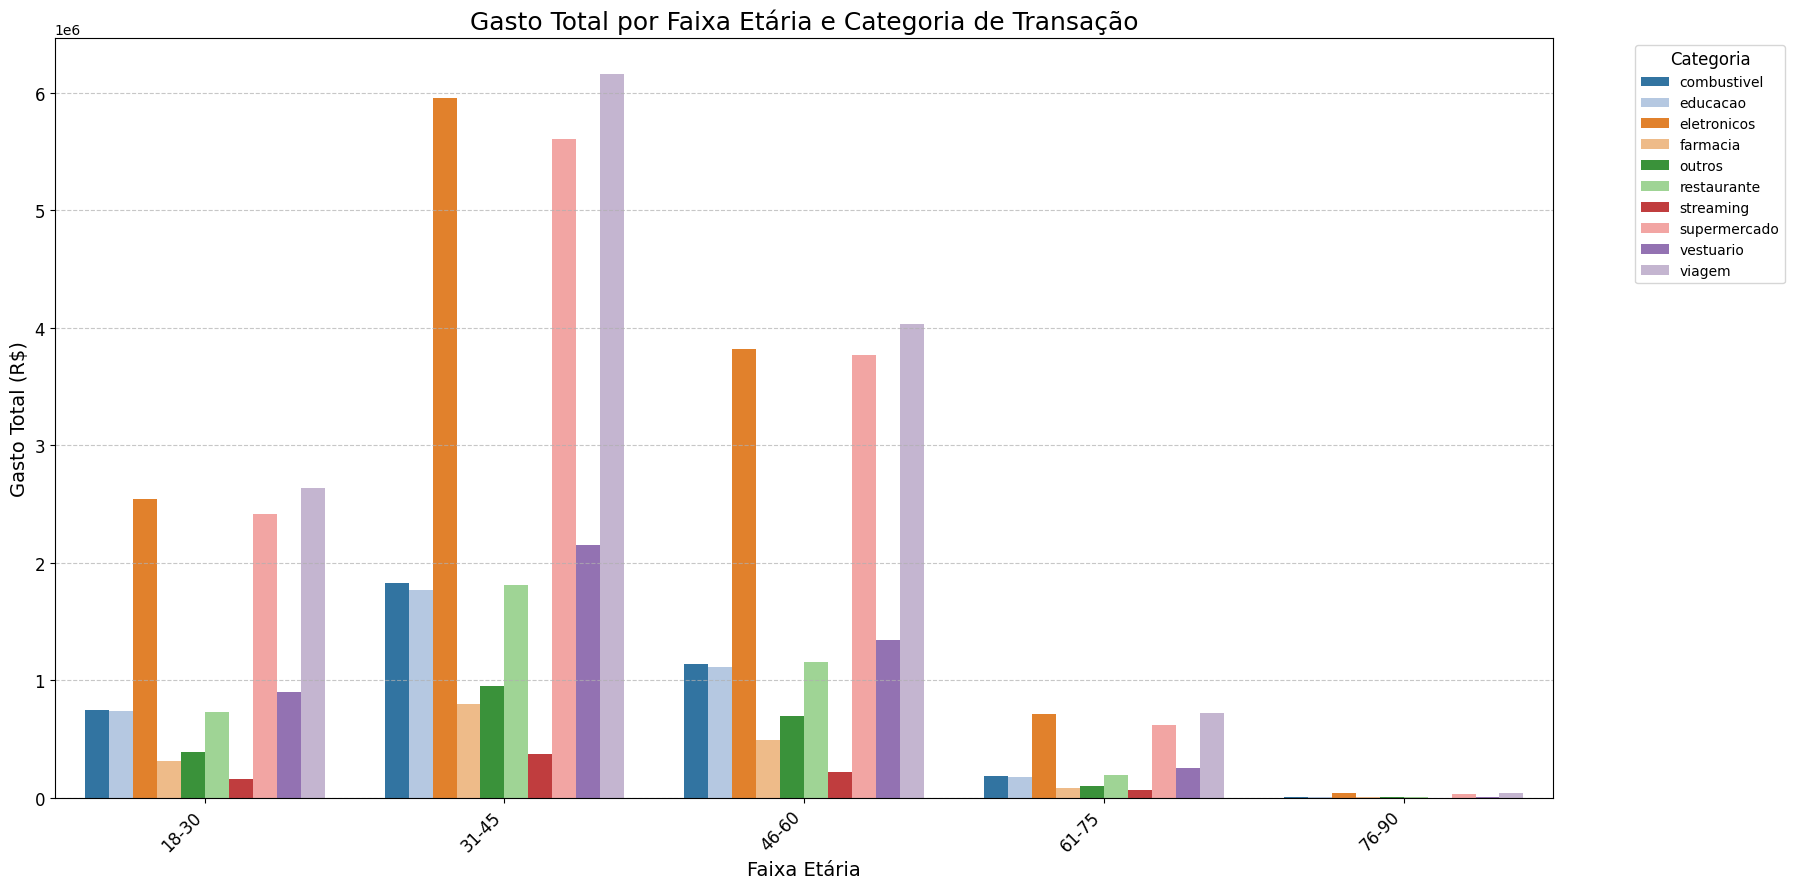

In [133]:
# Agrupar por faixa etária e categoria para calcular o gasto total
gasto_por_idade_categoria = df_merged.groupby(['faixa_etaria', 'categoria'], observed=False)['valor_transacao'].sum().reset_index()

# Criar o gráfico de barras agrupadas
plt.figure(figsize=(18, 9))
sns.barplot(data=gasto_por_idade_categoria, x='faixa_etaria', y='valor_transacao', hue='categoria', palette='tab20')
plt.title('Gasto Total por Faixa Etária e Categoria de Transação', fontsize=18)
plt.xlabel('Faixa Etária', fontsize=14)
plt.ylabel('Gasto Total (R$)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()